In [1]:
%cd ..

/home/bhchen/LearnKalmanGain


Current Working Directory: /home/bhchen/LearnKalmanGain

Successfully loaded data for: ['EtE+ES', 'EtE+ES+FT', 'MNMEF+ES', 'MNMEF+ES+FT', 'MNMEF+NL2', 'MNMEF+NL2+FT', 'EnKF', 'ESRF']
[Saved] mean_rcrps_absolute_sigma_1.0
[Saved] mean_rcrps_improvement_sigma_1.0
[Saved] mean_rrmse_absolute_sigma_1.0
[Saved] mean_rrmse_improvement_sigma_1.0
[Saved] time_absolute_sigma_1.0
[Saved] time_improvement_sigma_1.0
[Saved] shared_legend_sigma_1.0

Processing complete.


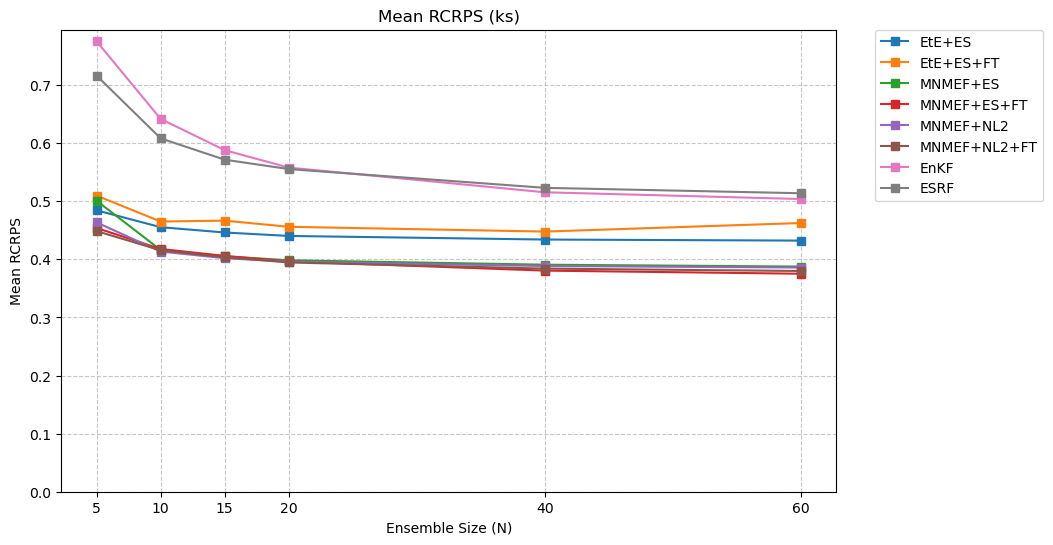

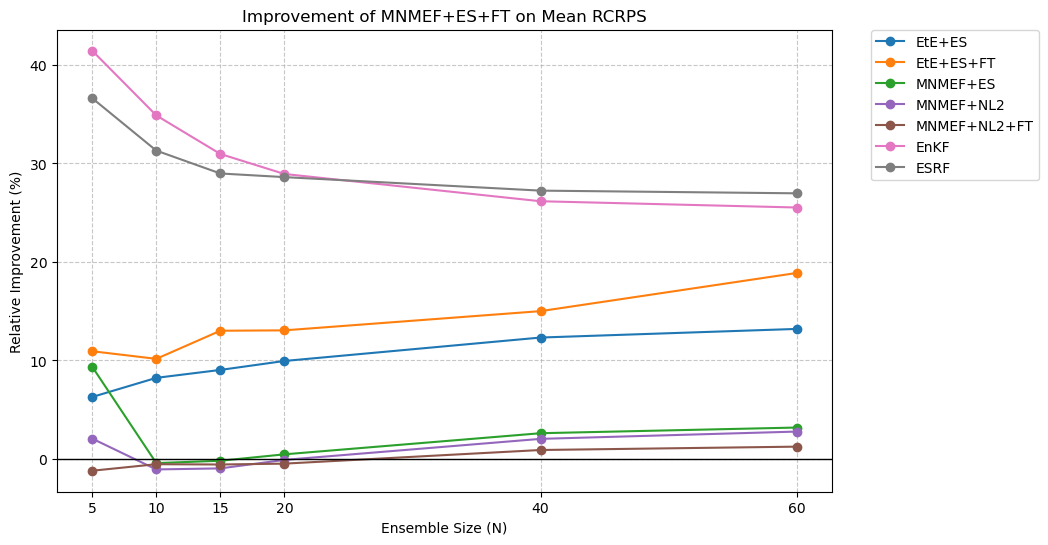

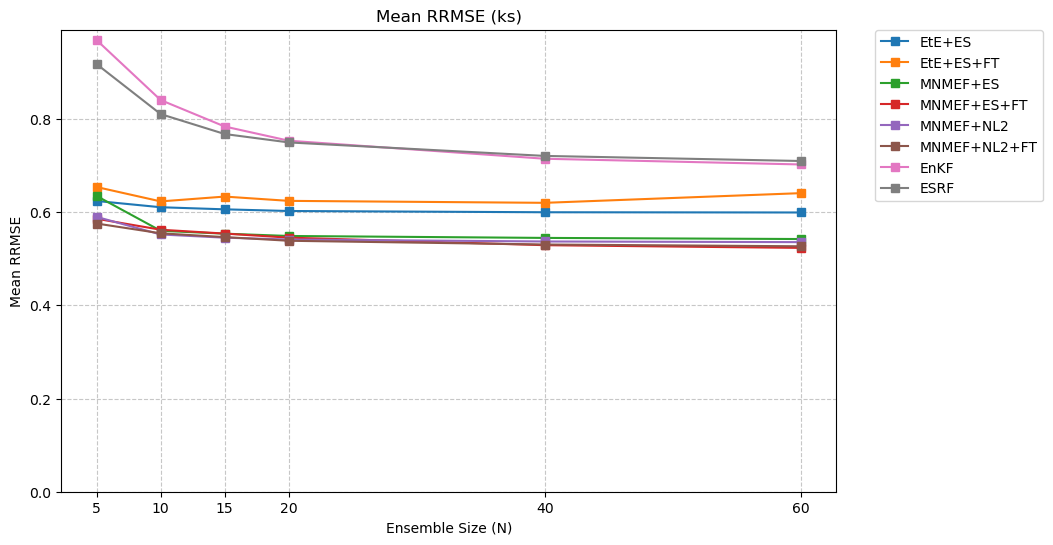

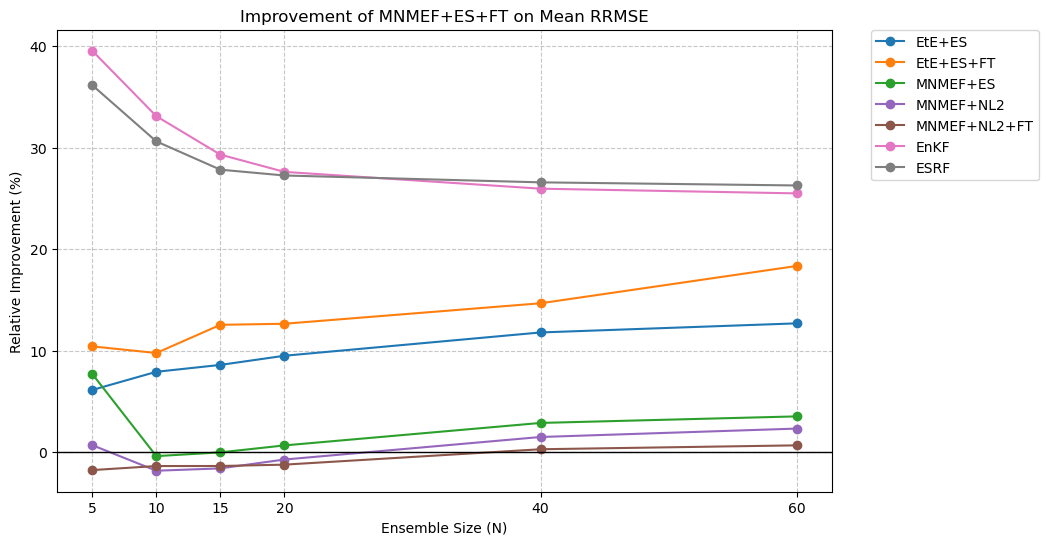

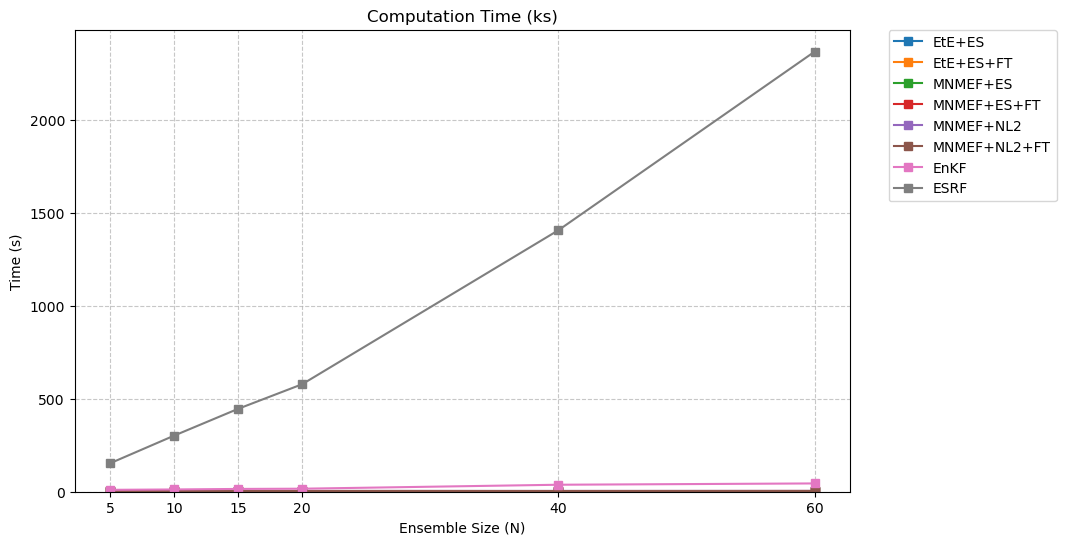

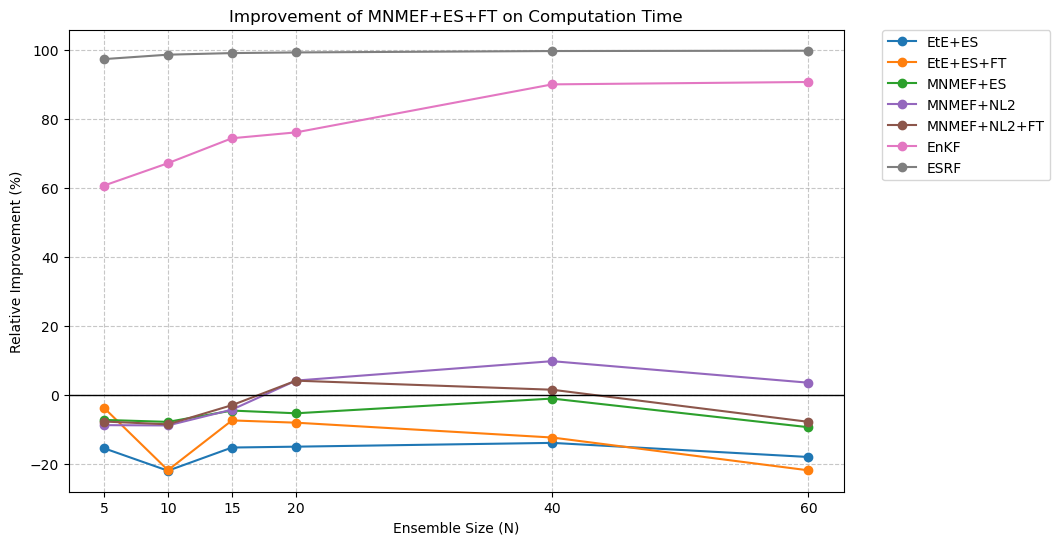

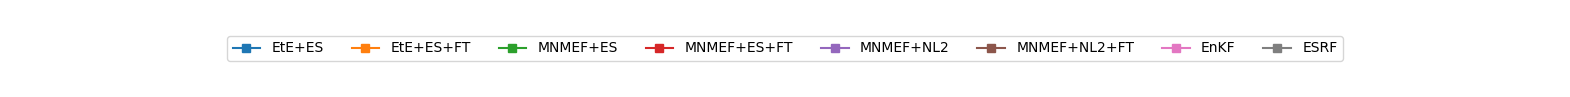

In [3]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np

# --- [CONFIGURATION & SETUP] ---
DATASET = "ks"
SIGMA_Y = 1.0 

# Dynamic Save Path
SAVE_DIR = os.path.join("save", "figures", f"{DATASET}_sigma{SIGMA_Y}")
os.makedirs(SAVE_DIR, exist_ok=True)

# Global flag to control legend visibility in individual plots
INCLUDE_LEGEND_IN_PLOTS = True 

ensemble_sizes = [5, 10, 15, 20, 40, 60]

data_folders = [
    "ks_EtE_LRes/2026-01-07_16-42ks_1.0_10_60_8192_es_joint_EtE-LRes",
    "ks_EtE_LRes/2026-01-21_19-33ks_1.0_20_60_8192_es_joint_EtE-LRes_tuned",
    "ks_EtE_LRes/2026-01-14_02-10ks_1.0_10_60_8192_es_joint_CorrTerms",
    "ks_EtE_LRes/2026-01-21_19-33ks_1.0_20_60_8192_es_joint_CorrTerms_tuned",
    "ks_EtE_LRes/2026-01-07_17-39ks_1.0_10_60_8192_nl2_joint_CorrTerms",
    "ks_EtE_LRes/2026-01-21_19-33ks_1.0_20_60_8192_nl2_joint_CorrTerms_tuned",
    "ks_benchmarks/benchmark_ks_1.0_EnKF",
    "ks_benchmarks/benchmark_ks_1.0_LETKF",
    # "ks_benchmarks/benchmark_ks_1.0_iEnKS-PertObs",
]

method_names = [
    'EtE+ES', 
    'EtE+ES+FT', 
    'MNMEF+ES',
    'MNMEF+ES+FT',
    'MNMEF+NL2',
    'MNMEF+NL2+FT',
    "EnKF",
    "ESRF",
    # "iEnKF-PertObs",
]

TARGET_METHOD = 'MNMEF+ES+FT'
# --- [COLOR MAPPING SETUP] ---
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']
METHOD_COLORS = {name: colors[i % len(colors)] for i, name in enumerate(method_names)}

# --- [DATA LOADING] ---
results = {}

print(f"Current Working Directory: {os.getcwd()}")

for i, folder in enumerate(data_folders):
    for ens_size in ensemble_sizes:
        filename = f"output_records_{ens_size}.pt"
        method_name = method_names[i]
        data_file = os.path.join("save", folder, filename)

        if not os.path.exists(data_file):
            print(f"\n[MISSING] File not found for {method_name} (N={ens_size})")
            continue

        try:
            data = torch.load(data_file, weights_only=True)
            
            # --- EXTRACT METRICS ---
            mean_rcrps = data["nn"].get('mean_rcrps', float('nan'))
            mean_rrmse = data["nn"].get('mean_rrmse', float('nan'))
            t = data["time"]

            results.setdefault(method_name, {})
            for key in ['mean_rcrps', 'mean_rrmse', 'time']:
                results[method_name].setdefault(key, [])

            results[method_name]['mean_rcrps'].append(mean_rcrps)
            results[method_name]['mean_rrmse'].append(mean_rrmse)
            results[method_name]['time'].append(t)
            
        except Exception as e:
            print(f"\n[ERROR] Failed to load {filename}: {e}")
            continue

if not results:
    raise RuntimeError("No data loaded.")
else:
    print(f"\nSuccessfully loaded data for: {list(results.keys())}")

# --- [HELPER FUNCTIONS] ---

def save_figure_and_log(fig, filename):
    """
    Saves figure to disk in PDF and PNG formats.
    Input: fig (matplotlib Figure), filename (string)
    Output: None
    """
    path_pdf = os.path.join(SAVE_DIR, f"{filename}.pdf")
    path_png = os.path.join(SAVE_DIR, f"{filename}.png")
    fig.savefig(path_pdf, bbox_inches='tight', format='pdf')
    fig.savefig(path_png, bbox_inches='tight', format='png', dpi=300)
    print(f"[Saved] {filename}")

def calculate_relative_improvement(metric_key):
    """
    Computes relative improvement of TARGET_METHOD compared to others.
    Input: metric_key (string)
    Output: dict {method_name: improvement_array}
    """
    if TARGET_METHOD not in results:
        return {}
    psef_vals = np.array(results[TARGET_METHOD][metric_key])
    imp_data = {}
    for method in results.keys():
        if method == TARGET_METHOD: continue 
        bench_vals = np.array(results[method][metric_key])
        improvement = (bench_vals - psef_vals) / bench_vals * 100
        imp_data[method] = improvement
    return imp_data

def add_legend_if_required(ax):
    """
    Adds a legend outside the plot area if the global flag is set.
    Input: ax (matplotlib Axes)
    Output: None
    """
    if INCLUDE_LEGEND_IN_PLOTS:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

def plot_metric_pair(metric_key, title_label, filename_base, ylabel=None):
    """
    Plots both absolute values and relative improvement for a metric side-by-side.
    Input: metric_key (str), title_label (str), filename_base (str), ylabel (str, optional)
    Output: None (saves files)
    """
    if ylabel is None: ylabel = title_label

    # --- 1. ABSOLUTE PLOT ---
    fig_abs, ax_abs = plt.subplots(figsize=(10, 6))
    for key in results.keys():
        if metric_key in results[key]:
            ax_abs.plot(ensemble_sizes, results[key][metric_key], marker='s', label=key, color=METHOD_COLORS[key])
    
    ax_abs.set_title(f'{title_label} ({DATASET})')
    ax_abs.set_xlabel('Ensemble Size (N)')
    ax_abs.set_ylabel(ylabel)
    ax_abs.set_xticks(ensemble_sizes)
    ax_abs.set_ylim(bottom=0)
    ax_abs.grid(True, linestyle='--', alpha=0.7)
    
    add_legend_if_required(ax_abs)
    save_figure_and_log(fig_abs, f"{filename_base}_absolute_sigma_{SIGMA_Y}")

    # --- 2. RELATIVE IMPROVEMENT PLOT ---
    imp_data = calculate_relative_improvement(metric_key)
    if imp_data:
        fig_rel, ax_rel = plt.subplots(figsize=(10, 6))
        for key, val in imp_data.items():
            ax_rel.plot(ensemble_sizes, val, marker='o', label=f"{key}", color=METHOD_COLORS[key])
        
        ax_rel.set_title(f'Improvement of {TARGET_METHOD} on {title_label}')
        ax_rel.set_xlabel('Ensemble Size (N)')
        ax_rel.set_ylabel('Relative Improvement (%)')
        ax_rel.set_xticks(ensemble_sizes)
        ax_rel.grid(True, linestyle='--', alpha=0.7)
        ax_rel.axhline(0, color='black', linewidth=1, linestyle='-') 
        
        add_legend_if_required(ax_rel)
        save_figure_and_log(fig_rel, f"{filename_base}_improvement_sigma_{SIGMA_Y}")

# --- [PLOTTING EXECUTION] ---

# Group 1: Mean RCRPS
plot_metric_pair(
    metric_key='mean_rcrps', 
    title_label='Mean RCRPS', 
    filename_base='mean_rcrps'
)

# Group 2: Mean RRMSE
plot_metric_pair(
    metric_key='mean_rrmse', 
    title_label='Mean RRMSE', 
    filename_base='mean_rrmse'
)

# Group 3: Computation Time
plot_metric_pair(
    metric_key='time', 
    title_label='Computation Time', 
    filename_base='time',
    ylabel='Time (s)'
)

# --- [SHARED LEGEND] ---
# Create a standalone legend file as backup
dummy_fig, dummy_ax = plt.subplots()
for key in results.keys():
    dummy_ax.plot([], [], marker='s', label=key, color=METHOD_COLORS[key])
handles, labels = dummy_ax.get_legend_handles_labels()
plt.close(dummy_fig)

fig_leg = plt.figure(figsize=(len(labels) * 2.5, 1.0))
ax_leg = fig_leg.add_subplot(111)
ax_leg.axis('off')
ax_leg.legend(handles, labels, loc='center', ncol=len(labels), frameon=True)
save_figure_and_log(fig_leg, f"shared_legend_sigma_{SIGMA_Y}")

print("\nProcessing complete.")

Current Working Directory: /home/bhchen/LearnKalmanGain

Successfully loaded data for: ['EtE+ES+FT', 'MNMEF+ES+FT', 'MNMEF+NL2+FT']
[Saved] mean_rcrps_absolute_sigma_1.0
[Saved] mean_rcrps_improvement_sigma_1.0
[Saved] mean_rrmse_absolute_sigma_1.0
[Saved] mean_rrmse_improvement_sigma_1.0
[Saved] time_absolute_sigma_1.0
[Saved] time_improvement_sigma_1.0
[Saved] shared_legend_sigma_1.0

Processing complete.


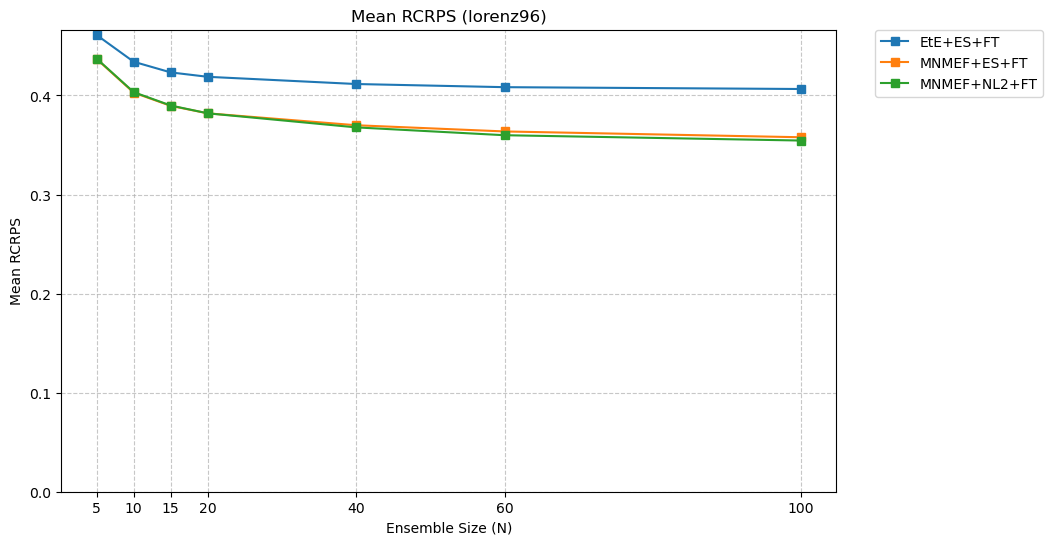

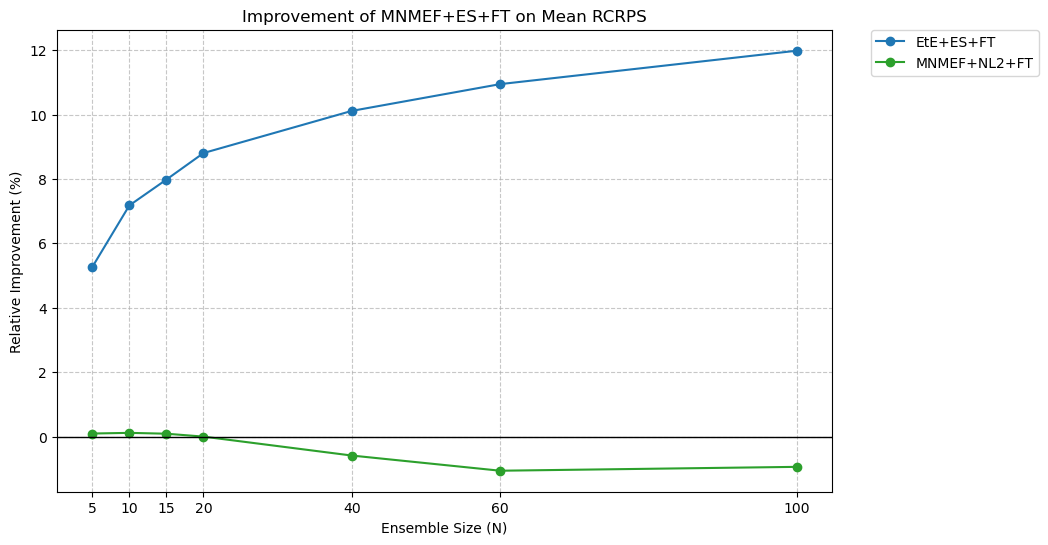

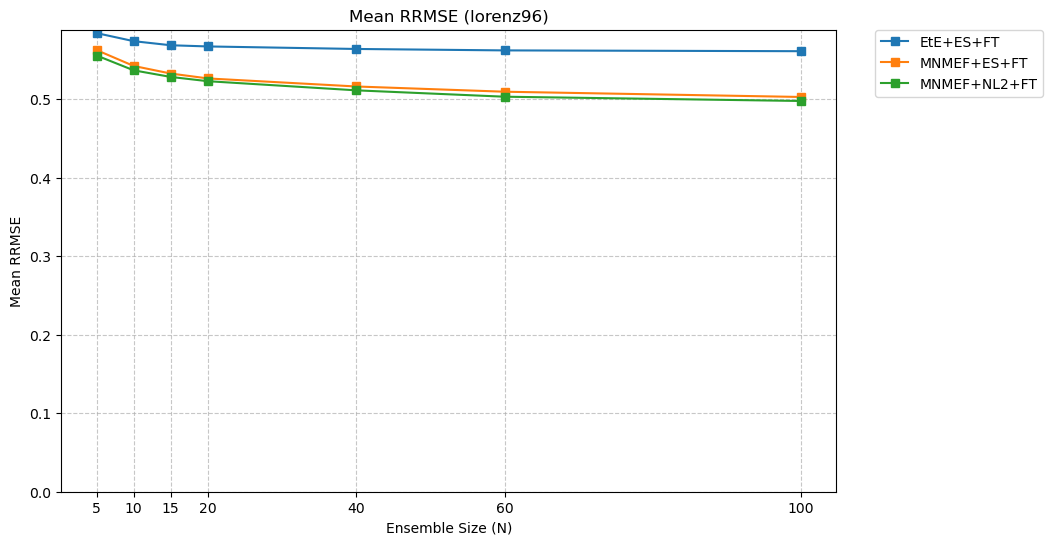

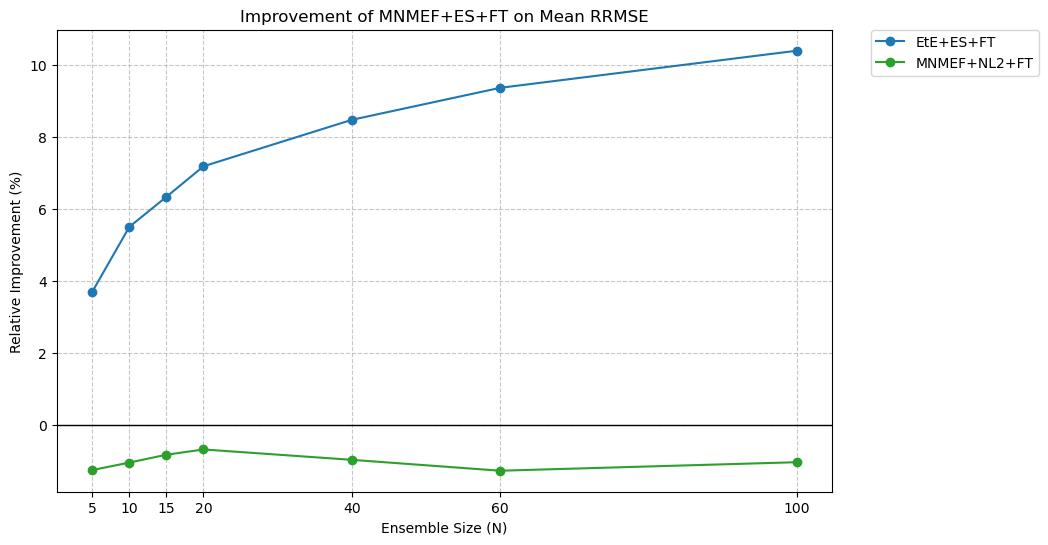

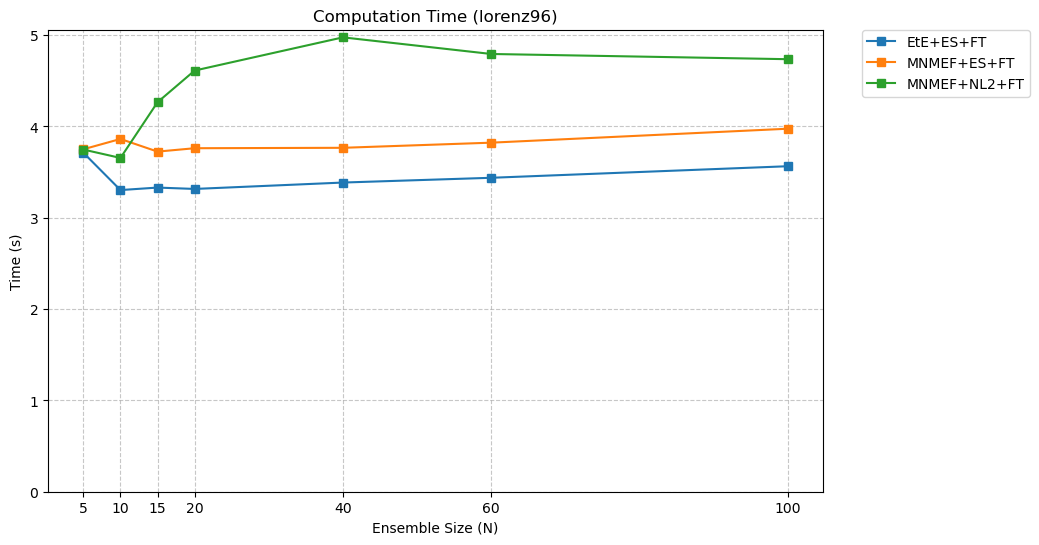

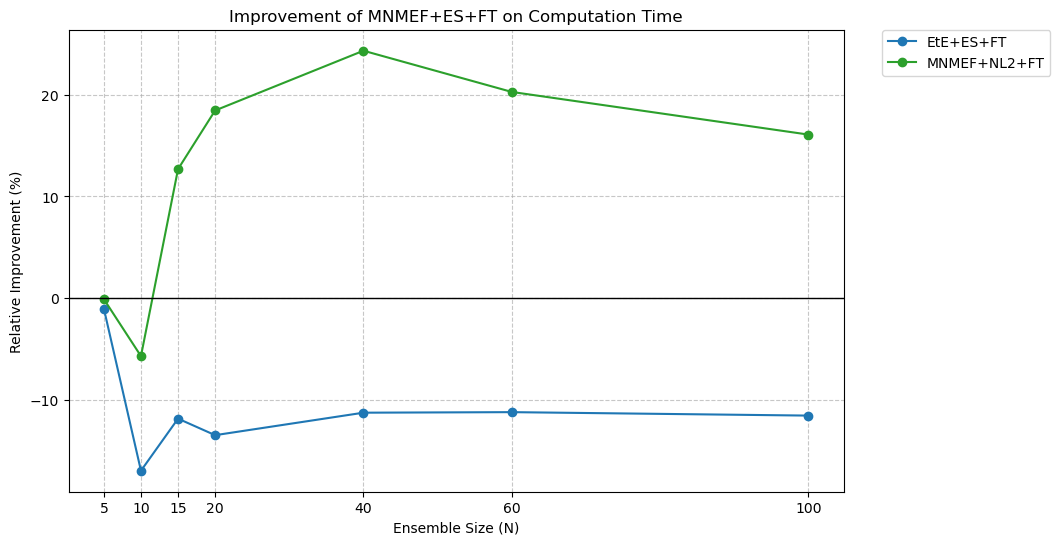

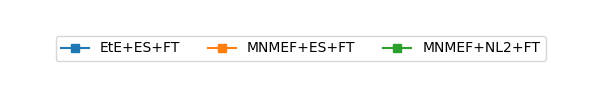

In [15]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np

# --- [CONFIGURATION & SETUP] ---
DATASET = "lorenz96"
SIGMA_Y = 1.0 

# Dynamic Save Path
SAVE_DIR = os.path.join("save", "figures", f"{DATASET}_sigma{SIGMA_Y}")
os.makedirs(SAVE_DIR, exist_ok=True)

# Global flag to control legend visibility in individual plots
INCLUDE_LEGEND_IN_PLOTS = True 

# suffix for data files
SUFFIX = f"_sigma_y_2_tuned"

ensemble_sizes = [5, 10, 15, 20, 40, 60, 100]

data_folders = [
    # "lorenz96_EtE_LRes/2026-01-07_16-42lorenz96_1.0_10_60_8192_es_joint_EtE-LRes",
    "lorenz96_EtE_LRes/2026-01-17_13-10lorenz96_1.0_20_60_8192_es_joint_EtE-LRes_tuned",
    # "lorenz96_EtE_LRes/2026-01-14_01-24lorenz96_1.0_10_60_8192_es_joint_CorrTerms",
    "lorenz96_EtE_LRes/2026-01-16_13-33lorenz96_1.0_20_60_8192_es_joint_CorrTerms_tuned",
    # "lorenz96_EtE_LRes/2026-01-07_17-39lorenz96_1.0_10_60_8192_nl2_joint_CorrTerms",
    "lorenz96_EtE_LRes/2026-01-17_01-16lorenz96_1.0_20_60_8192_nl2_joint_CorrTerms_tuned",
    # "lorenz96_benchmarks/benchmark_lorenz96_1.0_EnKF",
    # "lorenz96_benchmarks/benchmark_lorenz96_1.0_LETKF",
    # "lorenz96_benchmarks/benchmark_lorenz96_1.0_iEnKS-PertObs",
]

method_names = [
    # 'EtE+ES',
    'EtE+ES+FT', 
    # 'MNMEF+ES',
    'MNMEF+ES+FT',
    # 'MNMEF+NL2',
    'MNMEF+NL2+FT',
    # "EnKF",
    # "ESRF",
    # "iEnKF-PertObs",
]

TARGET_METHOD = 'MNMEF+ES+FT'

# --- [COLOR MAPPING SETUP] ---
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']
METHOD_COLORS = {name: colors[i % len(colors)] for i, name in enumerate(method_names)}

# --- [DATA LOADING] ---
results = {}

print(f"Current Working Directory: {os.getcwd()}")

for i, folder in enumerate(data_folders):
    for ens_size in ensemble_sizes:
        filename = f"output_records_{ens_size}{SUFFIX}.pt"
        method_name = method_names[i]
        data_file = os.path.join("save", folder, filename)

        if not os.path.exists(data_file):
            print(f"\n[MISSING] File not found for {method_name} (N={ens_size})")
            continue

        try:
            data = torch.load(data_file, weights_only=True)
            
            # --- EXTRACT METRICS ---
            mean_rcrps = data["nn"].get('mean_rcrps', float('nan'))
            mean_rrmse = data["nn"].get('mean_rrmse', float('nan'))
            t = data["time"]

            results.setdefault(method_name, {})
            for key in ['mean_rcrps', 'mean_rrmse', 'time']:
                results[method_name].setdefault(key, [])

            results[method_name]['mean_rcrps'].append(mean_rcrps)
            results[method_name]['mean_rrmse'].append(mean_rrmse)
            results[method_name]['time'].append(t)
            
        except Exception as e:
            print(f"\n[ERROR] Failed to load {filename}: {e}")
            continue

if not results:
    raise RuntimeError("No data loaded.")
else:
    print(f"\nSuccessfully loaded data for: {list(results.keys())}")

# --- [HELPER FUNCTIONS] ---

def save_figure_and_log(fig, filename):
    """
    Saves figure to disk in PDF and PNG formats.
    Input: fig (matplotlib Figure), filename (string)
    Output: None
    """
    path_pdf = os.path.join(SAVE_DIR, f"{filename}.pdf")
    path_png = os.path.join(SAVE_DIR, f"{filename}.png")
    fig.savefig(path_pdf, bbox_inches='tight', format='pdf')
    fig.savefig(path_png, bbox_inches='tight', format='png', dpi=300)
    print(f"[Saved] {filename}")

def calculate_relative_improvement(metric_key):
    """
    Computes relative improvement of TARGET_METHOD compared to others.
    Input: metric_key (string)
    Output: dict {method_name: improvement_array}
    """
    if TARGET_METHOD not in results:
        return {}
    psef_vals = np.array(results[TARGET_METHOD][metric_key])
    imp_data = {}
    for method in results.keys():
        if method == TARGET_METHOD: continue 
        bench_vals = np.array(results[method][metric_key])
        improvement = (bench_vals - psef_vals) / bench_vals * 100
        imp_data[method] = improvement
    return imp_data

def add_legend_if_required(ax):
    """
    Adds a legend outside the plot area if the global flag is set.
    Input: ax (matplotlib Axes)
    Output: None
    """
    if INCLUDE_LEGEND_IN_PLOTS:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

def plot_metric_pair(metric_key, title_label, filename_base, ylabel=None):
    """
    Plots both absolute values and relative improvement for a metric side-by-side.
    Input: metric_key (str), title_label (str), filename_base (str), ylabel (str, optional)
    Output: None (saves files)
    """
    if ylabel is None: ylabel = title_label

    # --- 1. ABSOLUTE PLOT ---
    fig_abs, ax_abs = plt.subplots(figsize=(10, 6))
    for key in results.keys():
        if metric_key in results[key]:
            ax_abs.plot(ensemble_sizes, results[key][metric_key], marker='s', label=key, color=METHOD_COLORS[key])
    
    ax_abs.set_title(f'{title_label} ({DATASET})')
    ax_abs.set_xlabel('Ensemble Size (N)')
    ax_abs.set_ylabel(ylabel)
    ax_abs.set_xticks(ensemble_sizes)
    ax_abs.set_ylim(bottom=0)
    ax_abs.grid(True, linestyle='--', alpha=0.7)
    
    add_legend_if_required(ax_abs)
    save_figure_and_log(fig_abs, f"{filename_base}_absolute_sigma_{SIGMA_Y}")

    # --- 2. RELATIVE IMPROVEMENT PLOT ---
    imp_data = calculate_relative_improvement(metric_key)
    if imp_data:
        fig_rel, ax_rel = plt.subplots(figsize=(10, 6))
        for key, val in imp_data.items():
            ax_rel.plot(ensemble_sizes, val, marker='o', label=f"{key}", color=METHOD_COLORS[key])
        
        ax_rel.set_title(f'Improvement of {TARGET_METHOD} on {title_label}')
        ax_rel.set_xlabel('Ensemble Size (N)')
        ax_rel.set_ylabel('Relative Improvement (%)')
        ax_rel.set_xticks(ensemble_sizes)
        ax_rel.grid(True, linestyle='--', alpha=0.7)
        ax_rel.axhline(0, color='black', linewidth=1, linestyle='-') 
        
        add_legend_if_required(ax_rel)
        save_figure_and_log(fig_rel, f"{filename_base}_improvement_sigma_{SIGMA_Y}")

# --- [PLOTTING EXECUTION] ---

# Group 1: Mean RCRPS
plot_metric_pair(
    metric_key='mean_rcrps', 
    title_label='Mean RCRPS', 
    filename_base='mean_rcrps'
)

# Group 2: Mean RRMSE
plot_metric_pair(
    metric_key='mean_rrmse', 
    title_label='Mean RRMSE', 
    filename_base='mean_rrmse'
)

# Group 3: Computation Time
plot_metric_pair(
    metric_key='time', 
    title_label='Computation Time', 
    filename_base='time',
    ylabel='Time (s)'
)

# --- [SHARED LEGEND] ---
# Create a standalone legend file as backup
dummy_fig, dummy_ax = plt.subplots()
for key in results.keys():
    dummy_ax.plot([], [], marker='s', label=key, color=METHOD_COLORS[key])
handles, labels = dummy_ax.get_legend_handles_labels()
plt.close(dummy_fig)

fig_leg = plt.figure(figsize=(len(labels) * 2.5, 1.0))
ax_leg = fig_leg.add_subplot(111)
ax_leg.axis('off')
ax_leg.legend(handles, labels, loc='center', ncol=len(labels), frameon=True)
save_figure_and_log(fig_leg, f"shared_legend_sigma_{SIGMA_Y}")

print("\nProcessing complete.")

Current Working Directory: /home/bhchen/LearnKalmanGain

Successfully loaded data for: ['EtE+ES', 'MNMEF+ES', 'MNMEF+NL2', 'EnKF', 'ESRF', 'iEnKF-PertObs']
[Saved] mean_rcrps_absolute_sigma_1.0
[Saved] mean_rrmse_absolute_sigma_1.0
[Saved] time_absolute_sigma_1.0
[Saved] shared_legend_sigma_1.0

Processing complete.


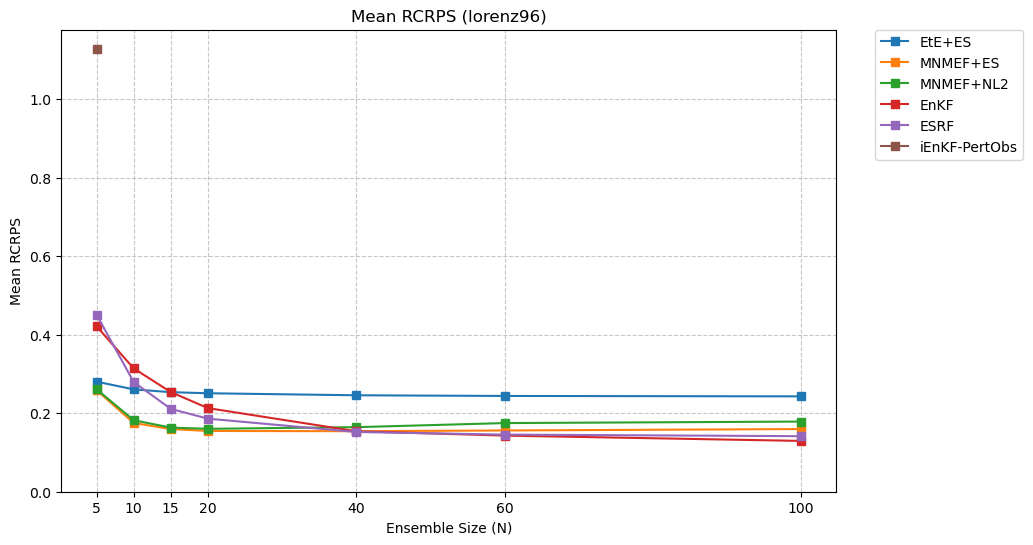

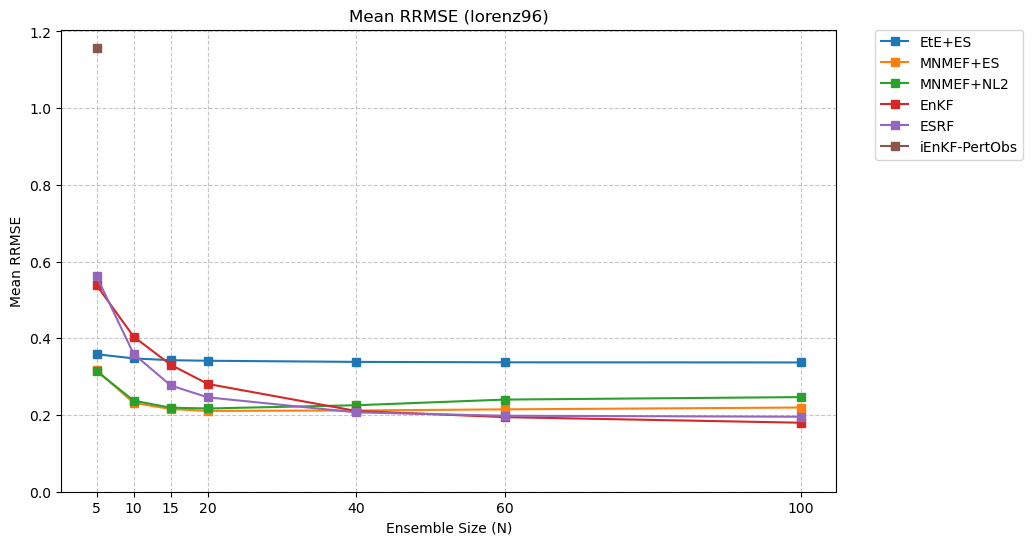

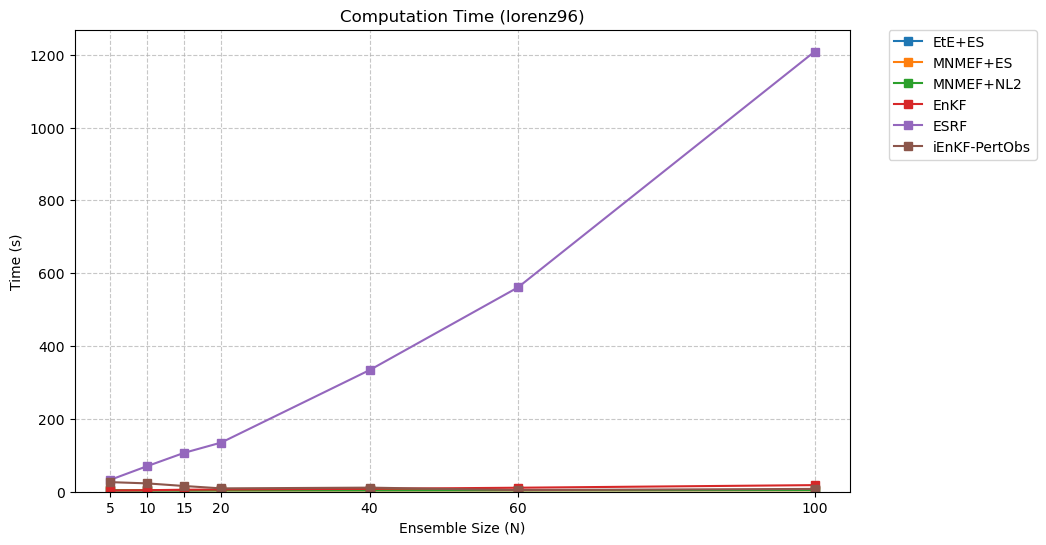

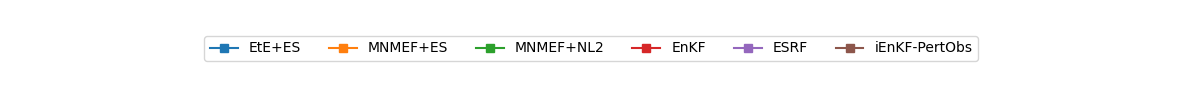

In [18]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np

# --- [CONFIGURATION & SETUP] ---
DATASET = "lorenz96"
SIGMA_Y = 1.0 

# Dynamic Save Path
SAVE_DIR = os.path.join("save", "figures", f"{DATASET}_sigma{SIGMA_Y}")
os.makedirs(SAVE_DIR, exist_ok=True)

# Global flag to control legend visibility in individual plots
INCLUDE_LEGEND_IN_PLOTS = True 

# suffix for data files
SUFFIX = f""

ensemble_sizes = [5, 10, 15, 20, 40, 60, 100]

data_folders = [
    "lorenz96_EtE_LRes/2026-01-14_18-05lorenz96_0.7_10_60_8192_es_joint_EtE-LRes",
    # "lorenz96_EtE_LRes/2026-01-17_13-10lorenz96_1.0_20_60_8192_es_joint_EtE-LRes_tuned",
    "lorenz96_EtE_LRes/2026-01-14_18-04lorenz96_0.7_10_60_8192_es_joint_CorrTerms",
    # "lorenz96_EtE_LRes/2026-01-16_13-33lorenz96_1.0_20_60_8192_es_joint_CorrTerms_tuned",
    "lorenz96_EtE_LRes/2026-01-14_18-05lorenz96_0.7_10_60_8192_nl2_joint_CorrTerms",
    # "lorenz96_EtE_LRes/2026-01-17_01-16lorenz96_1.0_20_60_8192_nl2_joint_CorrTerms_tuned",
    "lorenz96_benchmarks/benchmark_lorenz96_0.7_EnKF",
    "lorenz96_benchmarks/benchmark_lorenz96_0.7_LETKF",
    "lorenz96_benchmarks/benchmark_lorenz96_0.7_iEnKS-PertObs",
]

method_names = [
    'EtE+ES',
    # 'EtE+ES+FT', 
    'MNMEF+ES',
    # 'MNMEF+ES+FT',
    'MNMEF+NL2',
    # 'MNMEF+NL2+FT',
    "EnKF",
    "ESRF",
    "iEnKF-PertObs",
]

TARGET_METHOD = 'MNMEF+ES+FT'

# --- [COLOR MAPPING SETUP] ---
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']
METHOD_COLORS = {name: colors[i % len(colors)] for i, name in enumerate(method_names)}

# --- [DATA LOADING] ---
results = {}

print(f"Current Working Directory: {os.getcwd()}")

for i, folder in enumerate(data_folders):
    for ens_size in ensemble_sizes:
        filename = f"output_records_{ens_size}{SUFFIX}.pt"
        method_name = method_names[i]
        data_file = os.path.join("save", folder, filename)

        if not os.path.exists(data_file):
            print(f"\n[MISSING] File not found for {method_name} (N={ens_size})")
            continue

        try:
            data = torch.load(data_file, weights_only=True)
            
            # --- EXTRACT METRICS ---
            mean_rcrps = data["nn"].get('mean_rcrps', float('nan'))
            mean_rrmse = data["nn"].get('mean_rrmse', float('nan'))
            t = data["time"]

            results.setdefault(method_name, {})
            for key in ['mean_rcrps', 'mean_rrmse', 'time']:
                results[method_name].setdefault(key, [])

            results[method_name]['mean_rcrps'].append(mean_rcrps)
            results[method_name]['mean_rrmse'].append(mean_rrmse)
            results[method_name]['time'].append(t)
            
        except Exception as e:
            print(f"\n[ERROR] Failed to load {filename}: {e}")
            continue

if not results:
    raise RuntimeError("No data loaded.")
else:
    print(f"\nSuccessfully loaded data for: {list(results.keys())}")

# --- [HELPER FUNCTIONS] ---

def save_figure_and_log(fig, filename):
    """
    Saves figure to disk in PDF and PNG formats.
    Input: fig (matplotlib Figure), filename (string)
    Output: None
    """
    path_pdf = os.path.join(SAVE_DIR, f"{filename}.pdf")
    path_png = os.path.join(SAVE_DIR, f"{filename}.png")
    fig.savefig(path_pdf, bbox_inches='tight', format='pdf')
    fig.savefig(path_png, bbox_inches='tight', format='png', dpi=300)
    print(f"[Saved] {filename}")

def calculate_relative_improvement(metric_key):
    """
    Computes relative improvement of TARGET_METHOD compared to others.
    Input: metric_key (string)
    Output: dict {method_name: improvement_array}
    """
    if TARGET_METHOD not in results:
        return {}
    psef_vals = np.array(results[TARGET_METHOD][metric_key])
    imp_data = {}
    for method in results.keys():
        if method == TARGET_METHOD: continue 
        bench_vals = np.array(results[method][metric_key])
        improvement = (bench_vals - psef_vals) / bench_vals * 100
        imp_data[method] = improvement
    return imp_data

def add_legend_if_required(ax):
    """
    Adds a legend outside the plot area if the global flag is set.
    Input: ax (matplotlib Axes)
    Output: None
    """
    if INCLUDE_LEGEND_IN_PLOTS:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

def plot_metric_pair(metric_key, title_label, filename_base, ylabel=None):
    """
    Plots both absolute values and relative improvement for a metric side-by-side.
    Input: metric_key (str), title_label (str), filename_base (str), ylabel (str, optional)
    Output: None (saves files)
    """
    if ylabel is None: ylabel = title_label

    # --- 1. ABSOLUTE PLOT ---
    fig_abs, ax_abs = plt.subplots(figsize=(10, 6))
    for key in results.keys():
        if metric_key in results[key]:
            ax_abs.plot(ensemble_sizes, results[key][metric_key], marker='s', label=key, color=METHOD_COLORS[key])
    
    ax_abs.set_title(f'{title_label} ({DATASET})')
    ax_abs.set_xlabel('Ensemble Size (N)')
    ax_abs.set_ylabel(ylabel)
    ax_abs.set_xticks(ensemble_sizes)
    ax_abs.set_ylim(bottom=0)
    ax_abs.grid(True, linestyle='--', alpha=0.7)
    
    add_legend_if_required(ax_abs)
    save_figure_and_log(fig_abs, f"{filename_base}_absolute_sigma_{SIGMA_Y}")

    # --- 2. RELATIVE IMPROVEMENT PLOT ---
    imp_data = calculate_relative_improvement(metric_key)
    if imp_data:
        fig_rel, ax_rel = plt.subplots(figsize=(10, 6))
        for key, val in imp_data.items():
            ax_rel.plot(ensemble_sizes, val, marker='o', label=f"{key}", color=METHOD_COLORS[key])
        
        ax_rel.set_title(f'Improvement of {TARGET_METHOD} on {title_label}')
        ax_rel.set_xlabel('Ensemble Size (N)')
        ax_rel.set_ylabel('Relative Improvement (%)')
        ax_rel.set_xticks(ensemble_sizes)
        ax_rel.grid(True, linestyle='--', alpha=0.7)
        ax_rel.axhline(0, color='black', linewidth=1, linestyle='-') 
        
        add_legend_if_required(ax_rel)
        save_figure_and_log(fig_rel, f"{filename_base}_improvement_sigma_{SIGMA_Y}")

# --- [PLOTTING EXECUTION] ---

# Group 1: Mean RCRPS
plot_metric_pair(
    metric_key='mean_rcrps', 
    title_label='Mean RCRPS', 
    filename_base='mean_rcrps'
)

# Group 2: Mean RRMSE
plot_metric_pair(
    metric_key='mean_rrmse', 
    title_label='Mean RRMSE', 
    filename_base='mean_rrmse'
)

# Group 3: Computation Time
plot_metric_pair(
    metric_key='time', 
    title_label='Computation Time', 
    filename_base='time',
    ylabel='Time (s)'
)

# --- [SHARED LEGEND] ---
# Create a standalone legend file as backup
dummy_fig, dummy_ax = plt.subplots()
for key in results.keys():
    dummy_ax.plot([], [], marker='s', label=key, color=METHOD_COLORS[key])
handles, labels = dummy_ax.get_legend_handles_labels()
plt.close(dummy_fig)

fig_leg = plt.figure(figsize=(len(labels) * 2.5, 1.0))
ax_leg = fig_leg.add_subplot(111)
ax_leg.axis('off')
ax_leg.legend(handles, labels, loc='center', ncol=len(labels), frameon=True)
save_figure_and_log(fig_leg, f"shared_legend_sigma_{SIGMA_Y}")

print("\nProcessing complete.")